# AI-Based PPE Compliance Monitoring System

## Project Overview

This project develops an object detection system for identifying Personal Protective Equipment (PPE) in workplace and construction-site images.

The system uses a fine-tuned **YOLO26n** object detection model to detect four PPE-related classes:

- **Helmet**
- **NoHelmet**
- **Vest**
- **NoVest**

The final model is integrated into an interactive **Gradio application**, allowing users to upload an image and receive detected PPE objects, confidence scores, and a summary of detected PPE violations.

---

## Problem Definition

Monitoring PPE compliance manually can be time-consuming, especially when multiple workers or work areas need to be inspected.

The objective of this project is to develop a computer vision system capable of automatically detecting the presence or absence of two important types of PPE:

- Safety helmets
- Safety vests

The system is designed as an **object detection** solution, producing bounding boxes, class labels, and confidence scores for detected PPE conditions.

### Expected Output

For an input image, the system produces:

- PPE bounding boxes
- PPE class labels
- Detection confidence scores
- A summary of detected PPE violations

## Dataset

The final dataset used in this project is the **Personal Protective Equipment (PPE) Dataset — Version 6**, obtained from Mendeley Data.

**Dataset source:**  
https://data.mendeley.com/datasets/zkzghjvpn2/6

The dataset contains **2,286 images** in YOLO object-detection format with four classes.

| Class ID | Class |
|---:|---|
| 0 | Helmet |
| 1 | NoHelmet |
| 2 | NoVest |
| 3 | Vest |

### Dataset Split

The original dataset contained training and validation sets but did not provide a separate test set.

The original training set was retained, while the original validation set was divided into validation and test subsets using a fixed random seed (`42`).

| Split | Images | Purpose |
|---|---:|---|
| Train | 1,829 | Model fine-tuning |
| Validation | 228 | Model validation and checkpoint selection |
| Test | 229 | Final evaluation on unseen data |
| **Total** | **2,286** | |

Before training, the dataset structure and annotations were validated, and exact duplicate-image checks were performed between the training and validation data.

## Model Development

### Model Selection

YOLO26n was selected because the project requires object detection rather than image-level classification. The model can localize multiple PPE-related objects in a single image while simultaneously predicting their classes.

The nano variant was selected to provide a lightweight model suitable for experimentation and potential real-time deployment.

Pretrained YOLO26n weights were used as the initialization point instead of training the model from scratch. The model was then fine-tuned on the four-class PPE dataset using transfer learning.

No layers were manually frozen during training, allowing the model parameters to adapt to the target PPE detection task.
### Training Configuration

| Parameter | Value |
|---|---|
| Model | YOLO26n |
| Training Strategy | Full model fine-tuning |
| Epochs | 50 maximum |
| Image Size | 640 × 640 |
| Batch Size | 16 |
| Early Stopping Patience | 10 |
| GPU | NVIDIA Tesla T4 |
| Classes | 4 |

Training stopped through early stopping after **48 epochs**, with the best checkpoint obtained at **epoch 38**.

## System Workflow

The final system follows the pipeline below:

**PPE Dataset**  
↓  
**Data Validation & Preparation**  
↓  
**Train / Validation / Test Split**  
↓  
**Pretrained YOLO26n**  
↓  
**PPE Fine-Tuning**  
↓  
**Final Model Evaluation**  
↓  
**PPE Detection**  
↓  
**Bounding Boxes + Class Labels + Confidence Scores**  
↓  Violation Summary**  
↓  
**Gradio Application**

### Application Pipeline

At inference time:

**Uploaded Image → YOLO26n → Helmet / NoHelmet / Vest / NoVest → Detection Results → Compliance Summary**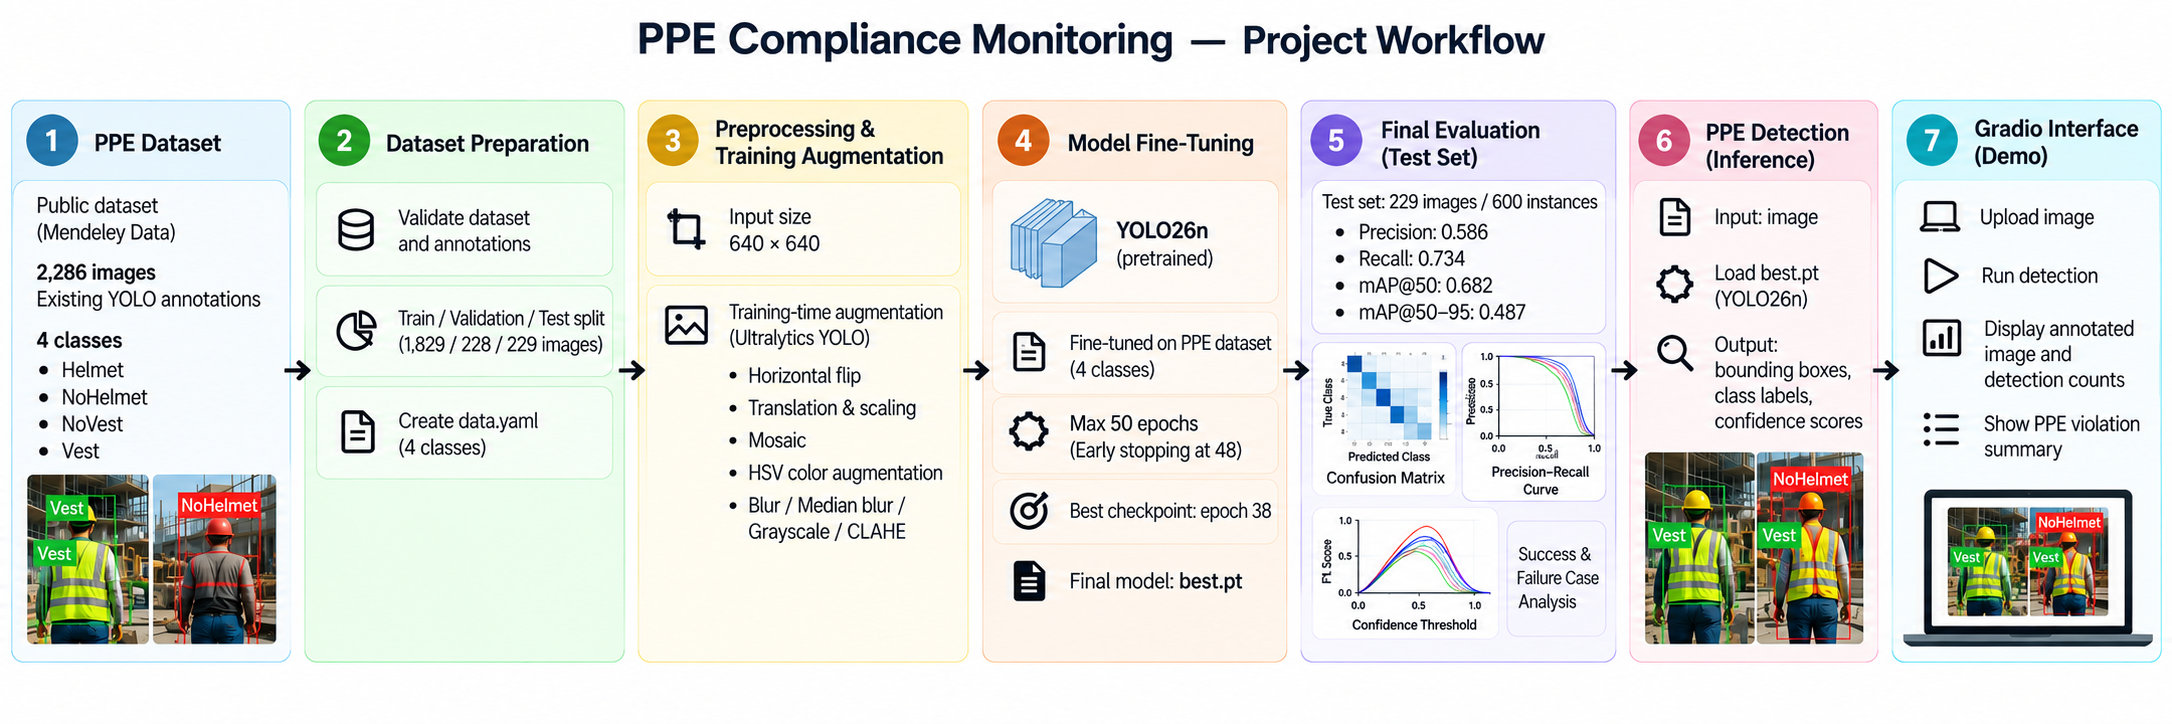

## Final Results Summary

The final fine-tuned YOLO26n model was evaluated on an unseen test set of **229 images containing 600 annotated objects**.

| Metric | Final Test Result |
|---|---:|
| Precision | 0.586 |
| Recall | 0.734 |
| mAP@50 | 0.682 |
| mAP@50–95 | 0.487 |

The model achieved its strongest class-level performance on **Vest** detection with an mAP@50 of **0.836**, while **NoVest** remained the most challenging class with an mAP@50 of **0.535**.

The final model was integrated into an interactive **Gradio application** for PPE detection and violation reporting on uploaded images.

In [2]:
# STEP 1A — Environment Setup
# Purpose: Install the Ultralytics package required for
# YOLO26n training, evaluation, and inference.
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 9.6 MB/s eta 0:00:00


In [2]:
# STEP 1B — Verify Environment
# Purpose: Verify PyTorch, Ultralytics, and GPU availability.

import torch
import ultralytics

print("PyTorch version:", torch.__version__)
print("Ultralytics version:", ultralytics.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
PyTorch version: 2.11.0+cu128
Ultralytics version: 8.4.168
GPU available: True
GPU: Tesla T4


In [3]:
# STEP 1C — Google Drive Setup
# Purpose: Mount Google Drive and define the project directory.

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

project_dir = Path("/content/drive/MyDrive/PPE_Compliance_Project")
project_dir.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/PPE_Compliance_Project


In [4]:
# STEP 1D — Extract the Downloaded Dataset
# Purpose: Extract the downloaded Mendeley PPE dataset package
# and inspect its initial folder structure.

from pathlib import Path
import zipfile

# Paths
project_dir = Path("/content/drive/MyDrive/PPE_Compliance_Project/datasets")
zip_path = project_dir / "PPE_Dataset.zip"

dataset_dir = project_dir / "PPE_Dataset"

# Check ZIP exists
print("ZIP exists:", zip_path.exists())

# Extract
dataset_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Dataset extracted to:")
print(dataset_dir)

# Show folder structure
print("\n--- Dataset Structure ---")

for path in sorted(dataset_dir.rglob("*")):
    if path.is_dir():
        print("📁", path.relative_to(dataset_dir))

ZIP exists: True
Dataset extracted to:
/content/drive/MyDrive/PPE_Compliance_Project/datasets/PPE_Dataset

--- Dataset Structure ---
📁 Dataset of Personal Protective Equipment (PPE)
📁 Dataset of Personal Protective Equipment (PPE)/PPE2286
📁 Dataset of Personal Protective Equipment (PPE)/PPE2286/20250731-ppe2286y
📁 Dataset of Personal Protective Equipment (PPE)/PPE2286/20250731-ppe2286y/train
📁 Dataset of Personal Protective Equipment (PPE)/PPE2286/20250731-ppe2286y/train/images
📁 Dataset of Personal Protective Equipment (PPE)/PPE2286/20250731-ppe2286y/train/labels
📁 Dataset of Personal Protective Equipment (PPE)/PPE2286/20250731-ppe2286y/valid
📁 Dataset of Personal Protective Equipment (PPE)/PPE2286/20250731-ppe2286y/valid/images
📁 Dataset of Personal Protective Equipment (PPE)/PPE2286/20250731-ppe2286y/valid/labels


In [5]:
# STEP 2 — Inspect Dataset Contents
# Purpose: Display the files and folders inside the main
# dataset directory to understand its structure before EDA.

from pathlib import Path

dataset_root = Path(
    "/content/drive/MyDrive/PPE_Compliance_Project/datasets/"
    "PPE_Dataset/Dataset of Personal Protective Equipment (PPE)"
)

print("Dataset root:", dataset_root)
print("Exists:", dataset_root.exists())

print("\n--- Main Contents ---")

for item in sorted(dataset_root.iterdir()):
    if item.is_dir():
        print(f"📁 {item.name}")
    else:
        print(f"📄 {item.name}")

Dataset root: /content/drive/MyDrive/PPE_Compliance_Project/datasets/PPE_Dataset/Dataset of Personal Protective Equipment (PPE)
Exists: True

--- Main Contents ---
📄 20250731-PPE2286y.zip
📁 PPE2286


In [ ]:
# STEP 3 — Extract the Inner PPE Dataset Archive
# Purpose: Extract the actual PPE dataset from the ZIP file
# contained inside the downloaded Mendeley package.

from pathlib import Path
import zipfile

inner_zip = dataset_root / "20250731-PPE2286y.zip"
final_dataset_dir = dataset_root / "PPE2286"

print("Inner ZIP exists:", inner_zip.exists())

# Extract the actual dataset
final_dataset_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(inner_zip, "r") as zip_ref:
    zip_ref.extractall(final_dataset_dir)

print("Dataset extracted to:")
print(final_dataset_dir)

# Display only the main contents after extraction
print("\n--- PPE Dataset Contents ---")

for item in sorted(final_dataset_dir.iterdir()):
    if item.is_dir():
        print(f"📁 {item.name}")
    else:
        print(f"📄 {item.name}")

In [8]:
# STEP 4 — Inspect the Final PPE Dataset Directory
# Purpose: Access the actual extracted dataset folder and
# inspect its top-level structure before data validation.

from pathlib import Path

ppe_dataset_path = final_dataset_dir / "20250731-ppe2286y"

print("Final dataset path:")
print(ppe_dataset_path)

print("\nExists:", ppe_dataset_path.exists())

print("\n--- Final Dataset Structure ---")

for item in sorted(ppe_dataset_path.iterdir()):
    if item.is_dir():
        print(f"📁 {item.name}")
    else:
        print(f"📄 {item.name}")

Final dataset path:
/content/drive/MyDrive/PPE_Compliance_Project/datasets/PPE_Dataset/Dataset of Personal Protective Equipment (PPE)/PPE2286/20250731-ppe2286y

Exists: True

--- Final Dataset Structure ---
📄 01_分割訓練及測試資料.py
📄 README.dataset.txt
📄 README.roboflow.txt
📄 data.yaml
📁 train
📁 valid


In [9]:
# STEP 5 — Validate Dataset Structure and Configuration
# Purpose: Read the YOLO configuration file and verify the
# dataset classes, splits, image counts, and label counts
# before performing EDA or model training.

from pathlib import Path
import yaml

# Load YOLO dataset configuration
yaml_path = ppe_dataset_path / "data.yaml"

with open(yaml_path, "r", encoding="utf-8") as file:
    dataset_config = yaml.safe_load(file)

print("--- Dataset Configuration ---")
print(dataset_config)

# Display class names
print("\n--- Classes ---")

class_names = dataset_config.get("names", {})

if isinstance(class_names, dict):
    for class_id, class_name in class_names.items():
        print(f"{class_id}: {class_name}")
else:
    for class_id, class_name in enumerate(class_names):
        print(f"{class_id}: {class_name}")

# Check dataset splits
print("\n--- Dataset Split Check ---")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "valid", "test"]:

    split_dir = ppe_dataset_path / split

    if not split_dir.exists():
        print(f"\n{split.upper()}: Not found")
        continue

    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    images = [
        f for f in images_dir.iterdir()
        if f.is_file() and f.suffix.lower() in image_extensions
    ] if images_dir.exists() else []

    labels = list(labels_dir.glob("*.txt")) if labels_dir.exists() else []

    image_stems = {f.stem for f in images}
    label_stems = {f.stem for f in labels}

    print(f"\n{split.upper()}")
    print(f"Images: {len(images)}")
    print(f"Labels: {len(labels)}")
    print(f"Images without labels: {len(image_stems - label_stems)}")
    print(f"Labels without images: {len(label_stems - image_stems)}")

--- Dataset Configuration ---
{'path': 'C:/Users/0/Desktop/ultralytics-8391/20250731-ppe2286y', 'train': './train/images', 'val': './valid/images', 'test': None, 'nc': 4, 'names': ['Helmet', 'NoHelmet', 'NoVest', 'Vest']}

--- Classes ---
0: Helmet
1: NoHelmet
2: NoVest
3: Vest

--- Dataset Split Check ---

TRAIN
Images: 1829
Labels: 1829
Images without labels: 0
Labels without images: 0

VALID
Images: 457
Labels: 457
Images without labels: 0
Labels without images: 0

TEST: Not found


--- TRAIN Class Distribution ---
Helmet: 1968
NoHelmet: 960
NoVest: 836
Vest: 1096

--- VALID Class Distribution ---
Helmet: 451
NoHelmet: 214
NoVest: 222
Vest: 289


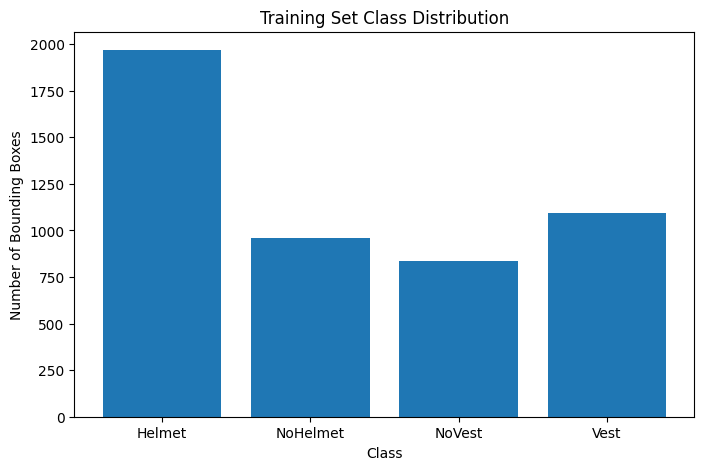

In [10]:
# STEP 6 — Analyze Class Distribution
# Purpose: Count the number of bounding-box annotations for
# each PPE class in the training and validation sets to detect
# possible class imbalance before model training.


from collections import Counter
import matplotlib.pyplot as plt

class_names = ["Helmet", "NoHelmet", "NoVest", "Vest"]

def count_annotations(labels_dir):
    counts = Counter()

    for label_file in labels_dir.glob("*.txt"):
        with open(label_file, "r") as file:
            for line in file:
                if line.strip():
                    class_id = int(line.split()[0])
                    counts[class_id] += 1

    return counts


# Count annotations
train_counts = count_annotations(
    ppe_dataset_path / "train" / "labels"
)

valid_counts = count_annotations(
    ppe_dataset_path / "valid" / "labels"
)


# Print results
print("--- TRAIN Class Distribution ---")

for class_id, class_name in enumerate(class_names):
    print(f"{class_name}: {train_counts[class_id]}")


print("\n--- VALID Class Distribution ---")

for class_id, class_name in enumerate(class_names):
    print(f"{class_name}: {valid_counts[class_id]}")


# Visualize training distribution
train_values = [
    train_counts[i]
    for i in range(len(class_names))
]

plt.figure(figsize=(8, 5))
plt.bar(class_names, train_values)

plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Bounding Boxes")

plt.show()

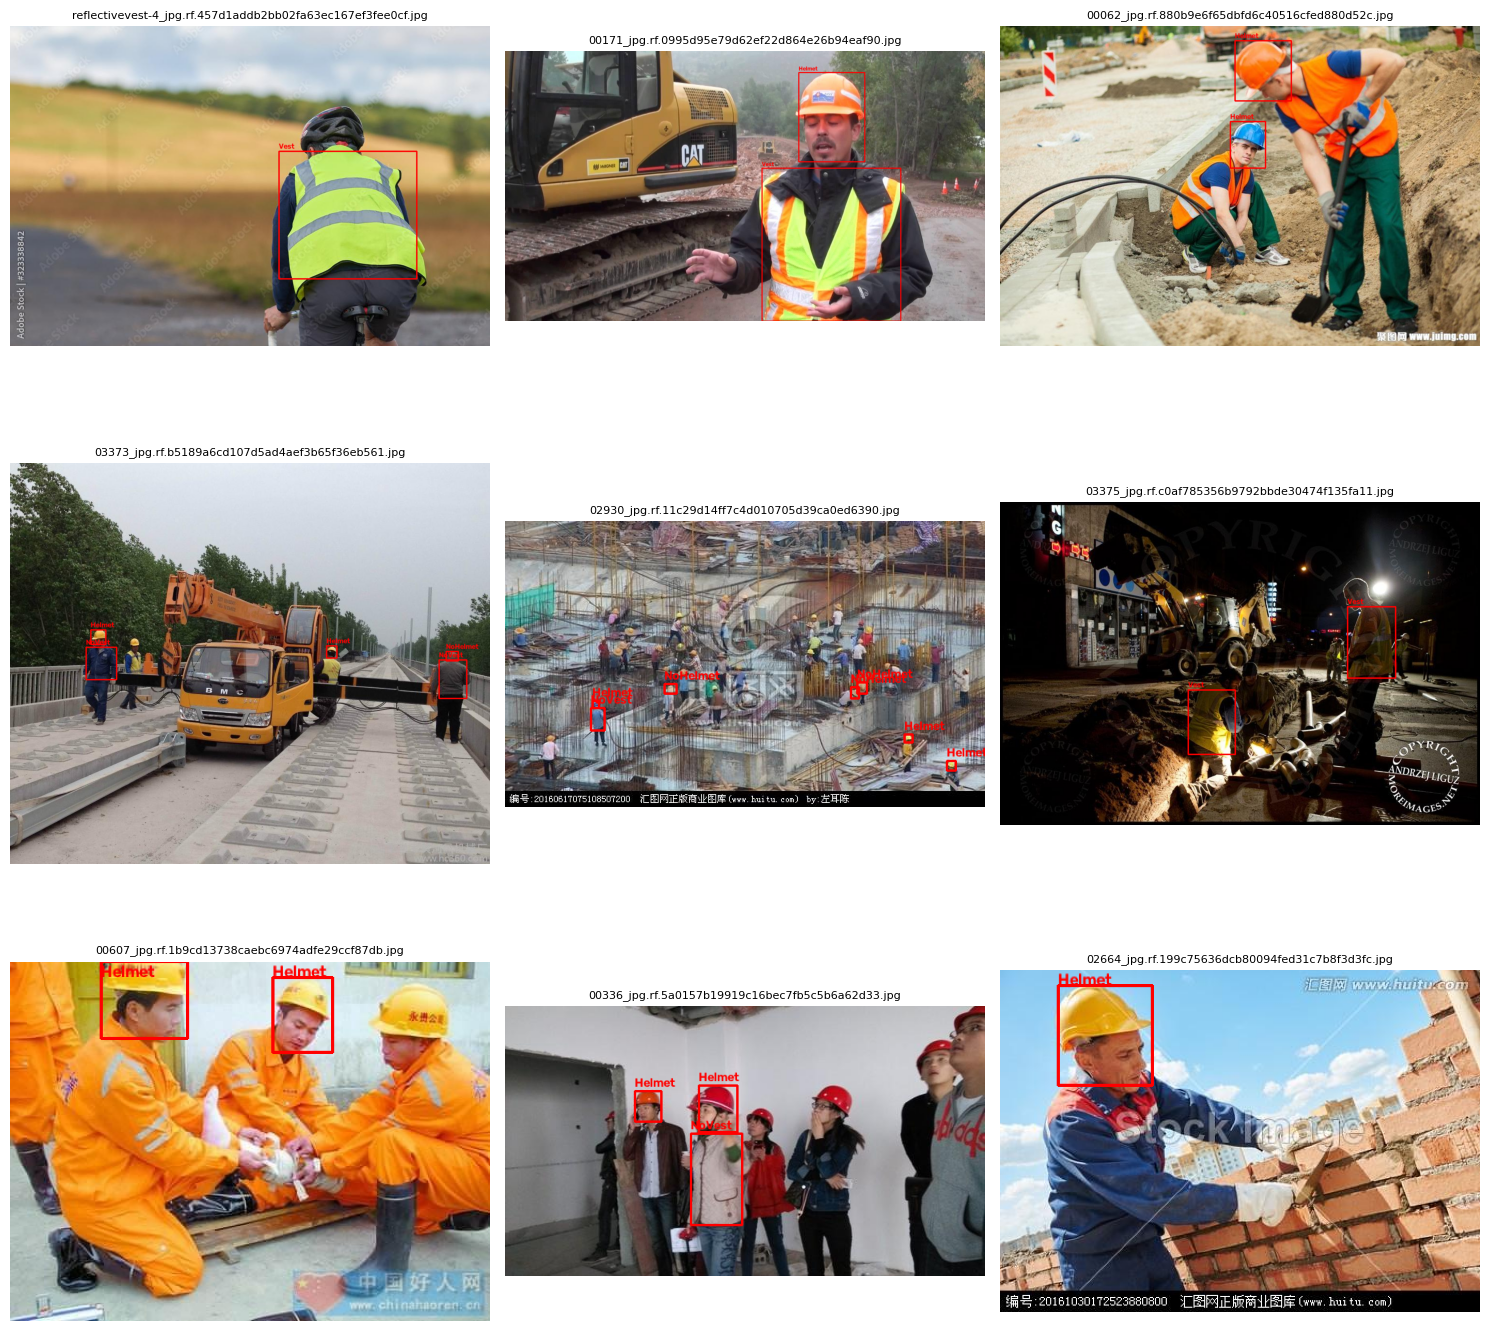

In [11]:
# STEP 7 — Visualize Random Annotated Training Samples
# Purpose: Display random training images with their ground-
# truth bounding boxes to visually inspect annotation quality,
# class correctness, and dataset relevance.

import random
import cv2
import matplotlib.pyplot as plt

class_names = ["Helmet", "NoHelmet", "NoVest", "Vest"]

images_dir = ppe_dataset_path / "train" / "images"
labels_dir = ppe_dataset_path / "train" / "labels"

image_files = [
    f for f in images_dir.iterdir()
    if f.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

# Select 9 random images
samples = random.sample(image_files, 9)

plt.figure(figsize=(15, 15))

for plot_index, image_path in enumerate(samples, start=1):

    # Read image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    height, width = image.shape[:2]

    # Find corresponding YOLO label file
    label_path = labels_dir / f"{image_path.stem}.txt"

    if label_path.exists():

        with open(label_path, "r") as file:

            for line in file:

                values = line.strip().split()

                if len(values) < 5:
                    continue

                class_id = int(values[0])

                x_center = float(values[1]) * width
                y_center = float(values[2]) * height
                box_width = float(values[3]) * width
                box_height = float(values[4]) * height

                x1 = int(x_center - box_width / 2)
                y1 = int(y_center - box_height / 2)
                x2 = int(x_center + box_width / 2)
                y2 = int(y_center + box_height / 2)

                # Draw bounding box
                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2
                )

                # Draw class name
                cv2.putText(
                    image,
                    class_names[class_id],
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255, 0, 0),
                    2
                )

    plt.subplot(3, 3, plot_index)
    plt.imshow(image)
    plt.title(image_path.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# STEP 8 — Check for Exact Duplicate Images and Data Leakage
# Purpose: Detect identical images within and across the
# training and validation sets using MD5 hashes before
# creating the final Train / Validation / Test split.

from pathlib import Path
from collections import defaultdict
import hashlib

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

train_images_dir = ppe_dataset_path / "train" / "images"
valid_images_dir = ppe_dataset_path / "valid" / "images"


# Function to calculate MD5 hash for an image
def get_file_hash(file_path):
    hash_md5 = hashlib.md5()

    with open(file_path, "rb") as file:
        for chunk in iter(lambda: file.read(4096), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


# Collect image paths
train_images = [
    f for f in train_images_dir.iterdir()
    if f.suffix.lower() in image_extensions
]

valid_images = [
    f for f in valid_images_dir.iterdir()
    if f.suffix.lower() in image_extensions
]


# Calculate hashes
train_hashes = defaultdict(list)
valid_hashes = defaultdict(list)

for image_path in train_images:
    train_hashes[get_file_hash(image_path)].append(image_path.name)

for image_path in valid_images:
    valid_hashes[get_file_hash(image_path)].append(image_path.name)


# Find duplicates inside each split
train_duplicates = {
    h: files
    for h, files in train_hashes.items()
    if len(files) > 1
}

valid_duplicates = {
    h: files
    for h, files in valid_hashes.items()
    if len(files) > 1
}


# Find identical images shared between Train and Validation
shared_hashes = set(train_hashes.keys()) & set(valid_hashes.keys())


print("--- Exact Duplicate Check ---")

print("\nTRAIN")
print("Images:", len(train_images))
print("Duplicate groups:", len(train_duplicates))

print("\nVALID")
print("Images:", len(valid_images))
print("Duplicate groups:", len(valid_duplicates))

print("\nTRAIN ↔ VALID")
print("Identical images shared across splits:", len(shared_hashes))


# Show examples if cross-split duplicates exist
if shared_hashes:

    print("\n--- Cross-Split Duplicate Examples ---")

    for i, image_hash in enumerate(shared_hashes):

        print("\nTrain:", train_hashes[image_hash])
        print("Valid:", valid_hashes[image_hash])

        if i == 9:   # Show maximum 10 examples
            break

else:
    print("\n✓ No exact duplicate images found between Train and Validation.")

--- Exact Duplicate Check ---

TRAIN
Images: 1829
Duplicate groups: 0

VALID
Images: 457
Duplicate groups: 0

TRAIN ↔ VALID
Identical images shared across splits: 0

✓ No exact duplicate images found between Train and Validation.


In [ ]:
# STEP 9 — Create Final Train / Validation / Test Dataset
# Purpose: Create the final dataset split as a one-time
# preparation step without modifying the original dataset.
# The safety check prevents accidental overwriting.

from pathlib import Path
import random
import shutil

# Paths
source_dataset = ppe_dataset_path

final_dataset = Path(
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "datasets/PPE_Dataset_Final"
)

# Safety check: avoid accidentally overwriting an existing copy
if final_dataset.exists():
    raise FileExistsError(
        f"{final_dataset} already exists.\n"
        "Delete it manually only if you intentionally want "
        "to recreate the final dataset."
    )

# Create final folder structure
for split in ["train", "valid", "test"]:
    (final_dataset / split / "images").mkdir(
        parents=True, exist_ok=True
    )
    (final_dataset / split / "labels").mkdir(
        parents=True, exist_ok=True
    )


# 1. Copy the original training set unchanged
for folder in ["images", "labels"]:
    source = source_dataset / "train" / folder
    destination = final_dataset / "train" / folder

    for file in source.iterdir():
        if file.is_file():
            shutil.copy2(file, destination / file.name)


# 2. Get original validation images

valid_images_source = source_dataset / "valid" / "images"
valid_labels_source = source_dataset / "valid" / "labels"

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

valid_images = [
    file for file in valid_images_source.iterdir()
    if file.suffix.lower() in image_extensions
]


# 3. Reproducible shuffle

random.seed(42)
random.shuffle(valid_images)

# 228 Validation + 229 Test
new_valid_images = valid_images[:228]
test_images = valid_images[228:]


# Helper function to copy image + matching YOLO label

def copy_image_and_label(image_path, split):

    # Copy image
    shutil.copy2(
        image_path,
        final_dataset / split / "images" / image_path.name
    )

    # Find corresponding label
    label_path = valid_labels_source / f"{image_path.stem}.txt"

    if not label_path.exists():
        raise FileNotFoundError(
            f"Missing label for: {image_path.name}"
        )

    # Copy label
    shutil.copy2(
        label_path,
        final_dataset / split / "labels" / label_path.name
    )



# 4. Create Validation and Test sets

for image_path in new_valid_images:
    copy_image_and_label(image_path, "valid")

for image_path in test_images:
    copy_image_and_label(image_path, "test")



# 5. Print final split

print("--- Final Dataset Created Successfully ---")

for split in ["train", "valid", "test"]:

    images_count = len(
        list((final_dataset / split / "images").iterdir())
    )

    labels_count = len(
        list((final_dataset / split / "labels").glob("*.txt"))
    )

    print(f"\n{split.upper()}")
    print("Images:", images_count)
    print("Labels:", labels_count)

print("\nTotal images:",
      sum(
          len(list((final_dataset / s / "images").iterdir()))
          for s in ["train", "valid", "test"]
      ))

print("\nFinal dataset path:")
print(final_dataset)

In [ ]:

# STEP 10 — Final Dataset Validation and YOLO Configuration
# Purpose: Verify the final Train / Validation / Test dataset
# integrity and create a correct data.yaml file for YOLO
# training and evaluation in Google Colab.


from pathlib import Path
import yaml


# Dataset configuration
final_dataset = Path(
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "datasets/PPE_Dataset_Final"
)

class_names = [
    "Helmet",
    "NoHelmet",
    "NoVest",
    "Vest"
]

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


# 1. Final integrity check
print("--- Final Dataset Integrity Check ---")

dataset_is_valid = True

for split in ["train", "valid", "test"]:

    images_dir = final_dataset / split / "images"
    labels_dir = final_dataset / split / "labels"

    images = [
        file for file in images_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    labels = list(labels_dir.glob("*.txt"))

    image_stems = {file.stem for file in images}
    label_stems = {file.stem for file in labels}

    missing_labels = image_stems - label_stems
    orphan_labels = label_stems - image_stems

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(orphan_labels))

    if missing_labels or orphan_labels:
        dataset_is_valid = False



# 2. Create YOLO data.yaml
data_config = {
    "path": str(final_dataset),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 4,
    "names": class_names
}

yaml_path = final_dataset / "data.yaml"

with open(yaml_path, "w", encoding="utf-8") as file:
    yaml.safe_dump(
        data_config,
        file,
        sort_keys=False,
        allow_unicode=True
    )


# 3. Display final configuration
print("\n--- YOLO Configuration ---")

with open(yaml_path, "r", encoding="utf-8") as file:
    print(file.read())

print("YAML saved to:")
print(yaml_path)



# Final status
if dataset_is_valid:
    print("\n✓ Final dataset is ready for model training.")
else:
    print("\n⚠ Dataset integrity issues detected.")

In [14]:
# STEP 11 — Fine-Tune YOLO26n on the Final PPE Dataset
# Purpose: Fine-tune a pretrained YOLO26n model on the
# four-class PPE dataset using transfer learning.

from ultralytics import YOLO

# Path to the final YOLO dataset configuration
yaml_path = (
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "datasets/PPE_Dataset_Final/data.yaml"
)

# Load pretrained YOLO26n weights
model = YOLO("yolo26n.pt")

# Fine-tune on the refined PPE dataset
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    patience=10,
    pretrained=True,
    plots=True,

    # Save experiment permanently to Google Drive
    project="/content/drive/MyDrive/PPE_Compliance_Project/runs",
    name="refined_data_baseline_yolo26n"
)

Ultralytics 8.4.168 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PPE_Compliance_Project/datasets/PPE_Dataset_Final/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=refine

## Preprocessing and Data Augmentation

Input images were processed at a resolution of **640 × 640 pixels** during model training.

Data augmentation was applied automatically through the Ultralytics YOLO training pipeline to improve model generalization. The training augmentations included:

- **Horizontal flipping**
- **Translation and scaling**
- **Mosaic augmentation**
- **HSV color augmentation**
- Low-probability **Blur, Median Blur, Grayscale, and CLAHE** transformations

These augmentations were applied during training, while the validation and test sets were used for model evaluation without training-time augmentation.

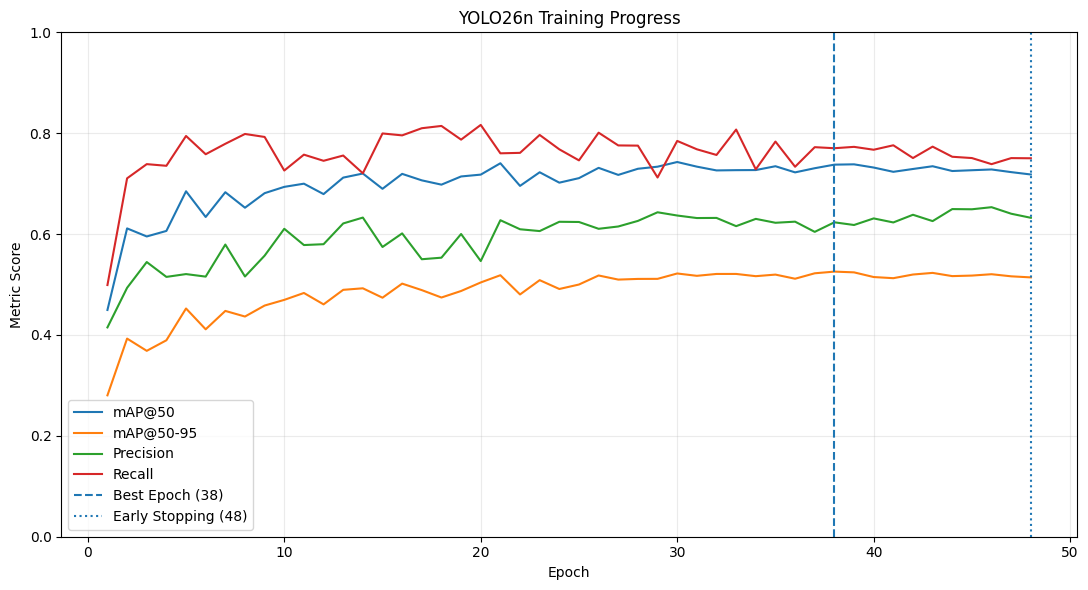

In [16]:
# STEP 11A — Visualize Training Progress
# Purpose: Display the training and validation performance
# across epochs and highlight the best checkpoint and the
# epoch at which early stopping occurred.

import pandas as pd
import matplotlib.pyplot as plt

results_csv = (
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "runs/refined_data_baseline_yolo26n/results.csv"
)

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

best_epoch = 38
stopped_epoch = 48

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df["epoch"],
    df["metrics/mAP50(B)"],
    label="mAP@50"
)

ax.plot(
    df["epoch"],
    df["metrics/mAP50-95(B)"],
    label="mAP@50-95"
)

ax.plot(
    df["epoch"],
    df["metrics/precision(B)"],
    label="Precision"
)

ax.plot(
    df["epoch"],
    df["metrics/recall(B)"],
    label="Recall"
)

ax.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best Epoch ({best_epoch})"
)

ax.axvline(
    stopped_epoch,
    linestyle=":",
    label=f"Early Stopping ({stopped_epoch})"
)

ax.set_title("YOLO26n Training Progress")
ax.set_xlabel("Epoch")
ax.set_ylabel("Metric Score")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

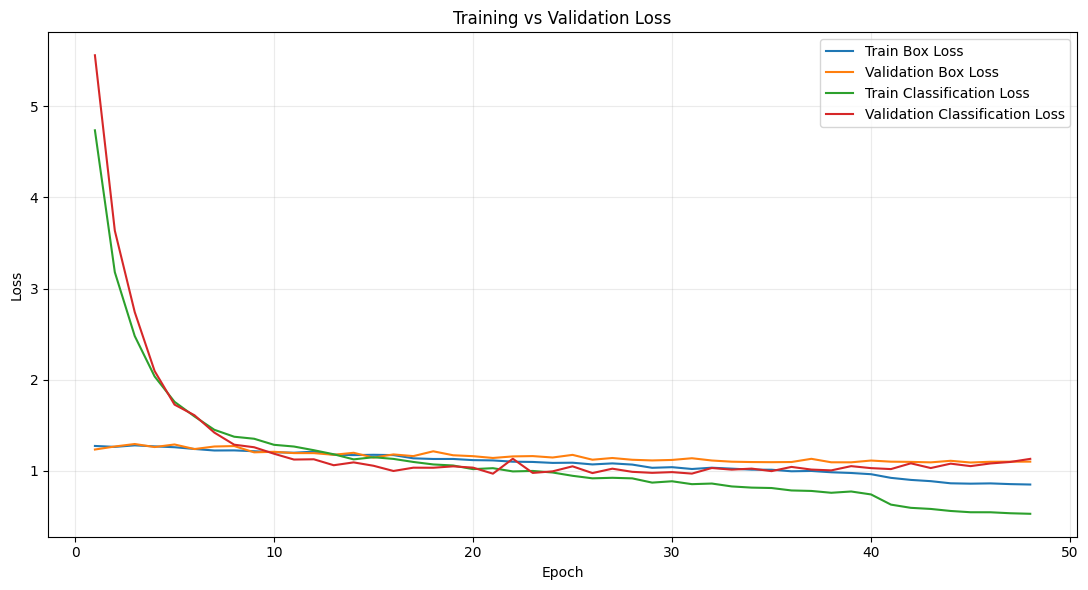

In [17]:
# STEP 11B — Visualize Training and Validation Loss
# Purpose: Compare training and validation losses across
# epochs to inspect model convergence and generalization.

import pandas as pd
import matplotlib.pyplot as plt

results_csv = (
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "runs/refined_data_baseline_yolo26n/results.csv"
)

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    df["epoch"],
    df["train/box_loss"],
    label="Train Box Loss"
)

ax.plot(
    df["epoch"],
    df["val/box_loss"],
    label="Validation Box Loss"
)

ax.plot(
    df["epoch"],
    df["train/cls_loss"],
    label="Train Classification Loss"
)

ax.plot(
    df["epoch"],
    df["val/cls_loss"],
    label="Validation Classification Loss"
)

ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [6]:

# STEP 12 — Final Model Evaluation on the Test Set
# Purpose: Evaluate the best refined YOLO26n model on the
# unseen test set and report its final generalization metrics.

from ultralytics import YOLO


# Paths

best_model_path = (
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "runs/refined_data_baseline_yolo26n/weights/best.pt"
)

yaml_path = (
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "datasets/PPE_Dataset_Final/data.yaml"
)



# Load the best trained model


final_model = YOLO(best_model_path)

print("✓ Best model loaded successfully.")


# Evaluate ONLY on the unseen Test set
test_results = final_model.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,

    project="/content/drive/MyDrive/PPE_Compliance_Project/runs",
    name="final_test_evaluation"
)


# Display final test metrics

print("\n--- FINAL TEST RESULTS ---")

print(f"Precision:   {test_results.box.mp:.4f}")
print(f"Recall:      {test_results.box.mr:.4f}")
print(f"mAP@50:      {test_results.box.map50:.4f}")
print(f"mAP@50-95:   {test_results.box.map:.4f}")

✓ Best model loaded successfully.
Ultralytics 8.4.168 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,616 parameters, 0 gradients, 5.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 2.9±5.0 ms, read: 1.5±3.1 MB/s, size: 45.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/PPE_Compliance_Project/datasets/PPE_Dataset_Final/test/labels... 229 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 229/229 1.8it/s 2:07
val: New cache created: /content/drive/MyDrive/PPE_Compliance_Project/datasets/PPE_Dataset_Final/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 1.6it/s 9.2s
                   all        229        600      0.586      0.734      0.682      0.487
                Helmet        129        228      0.506

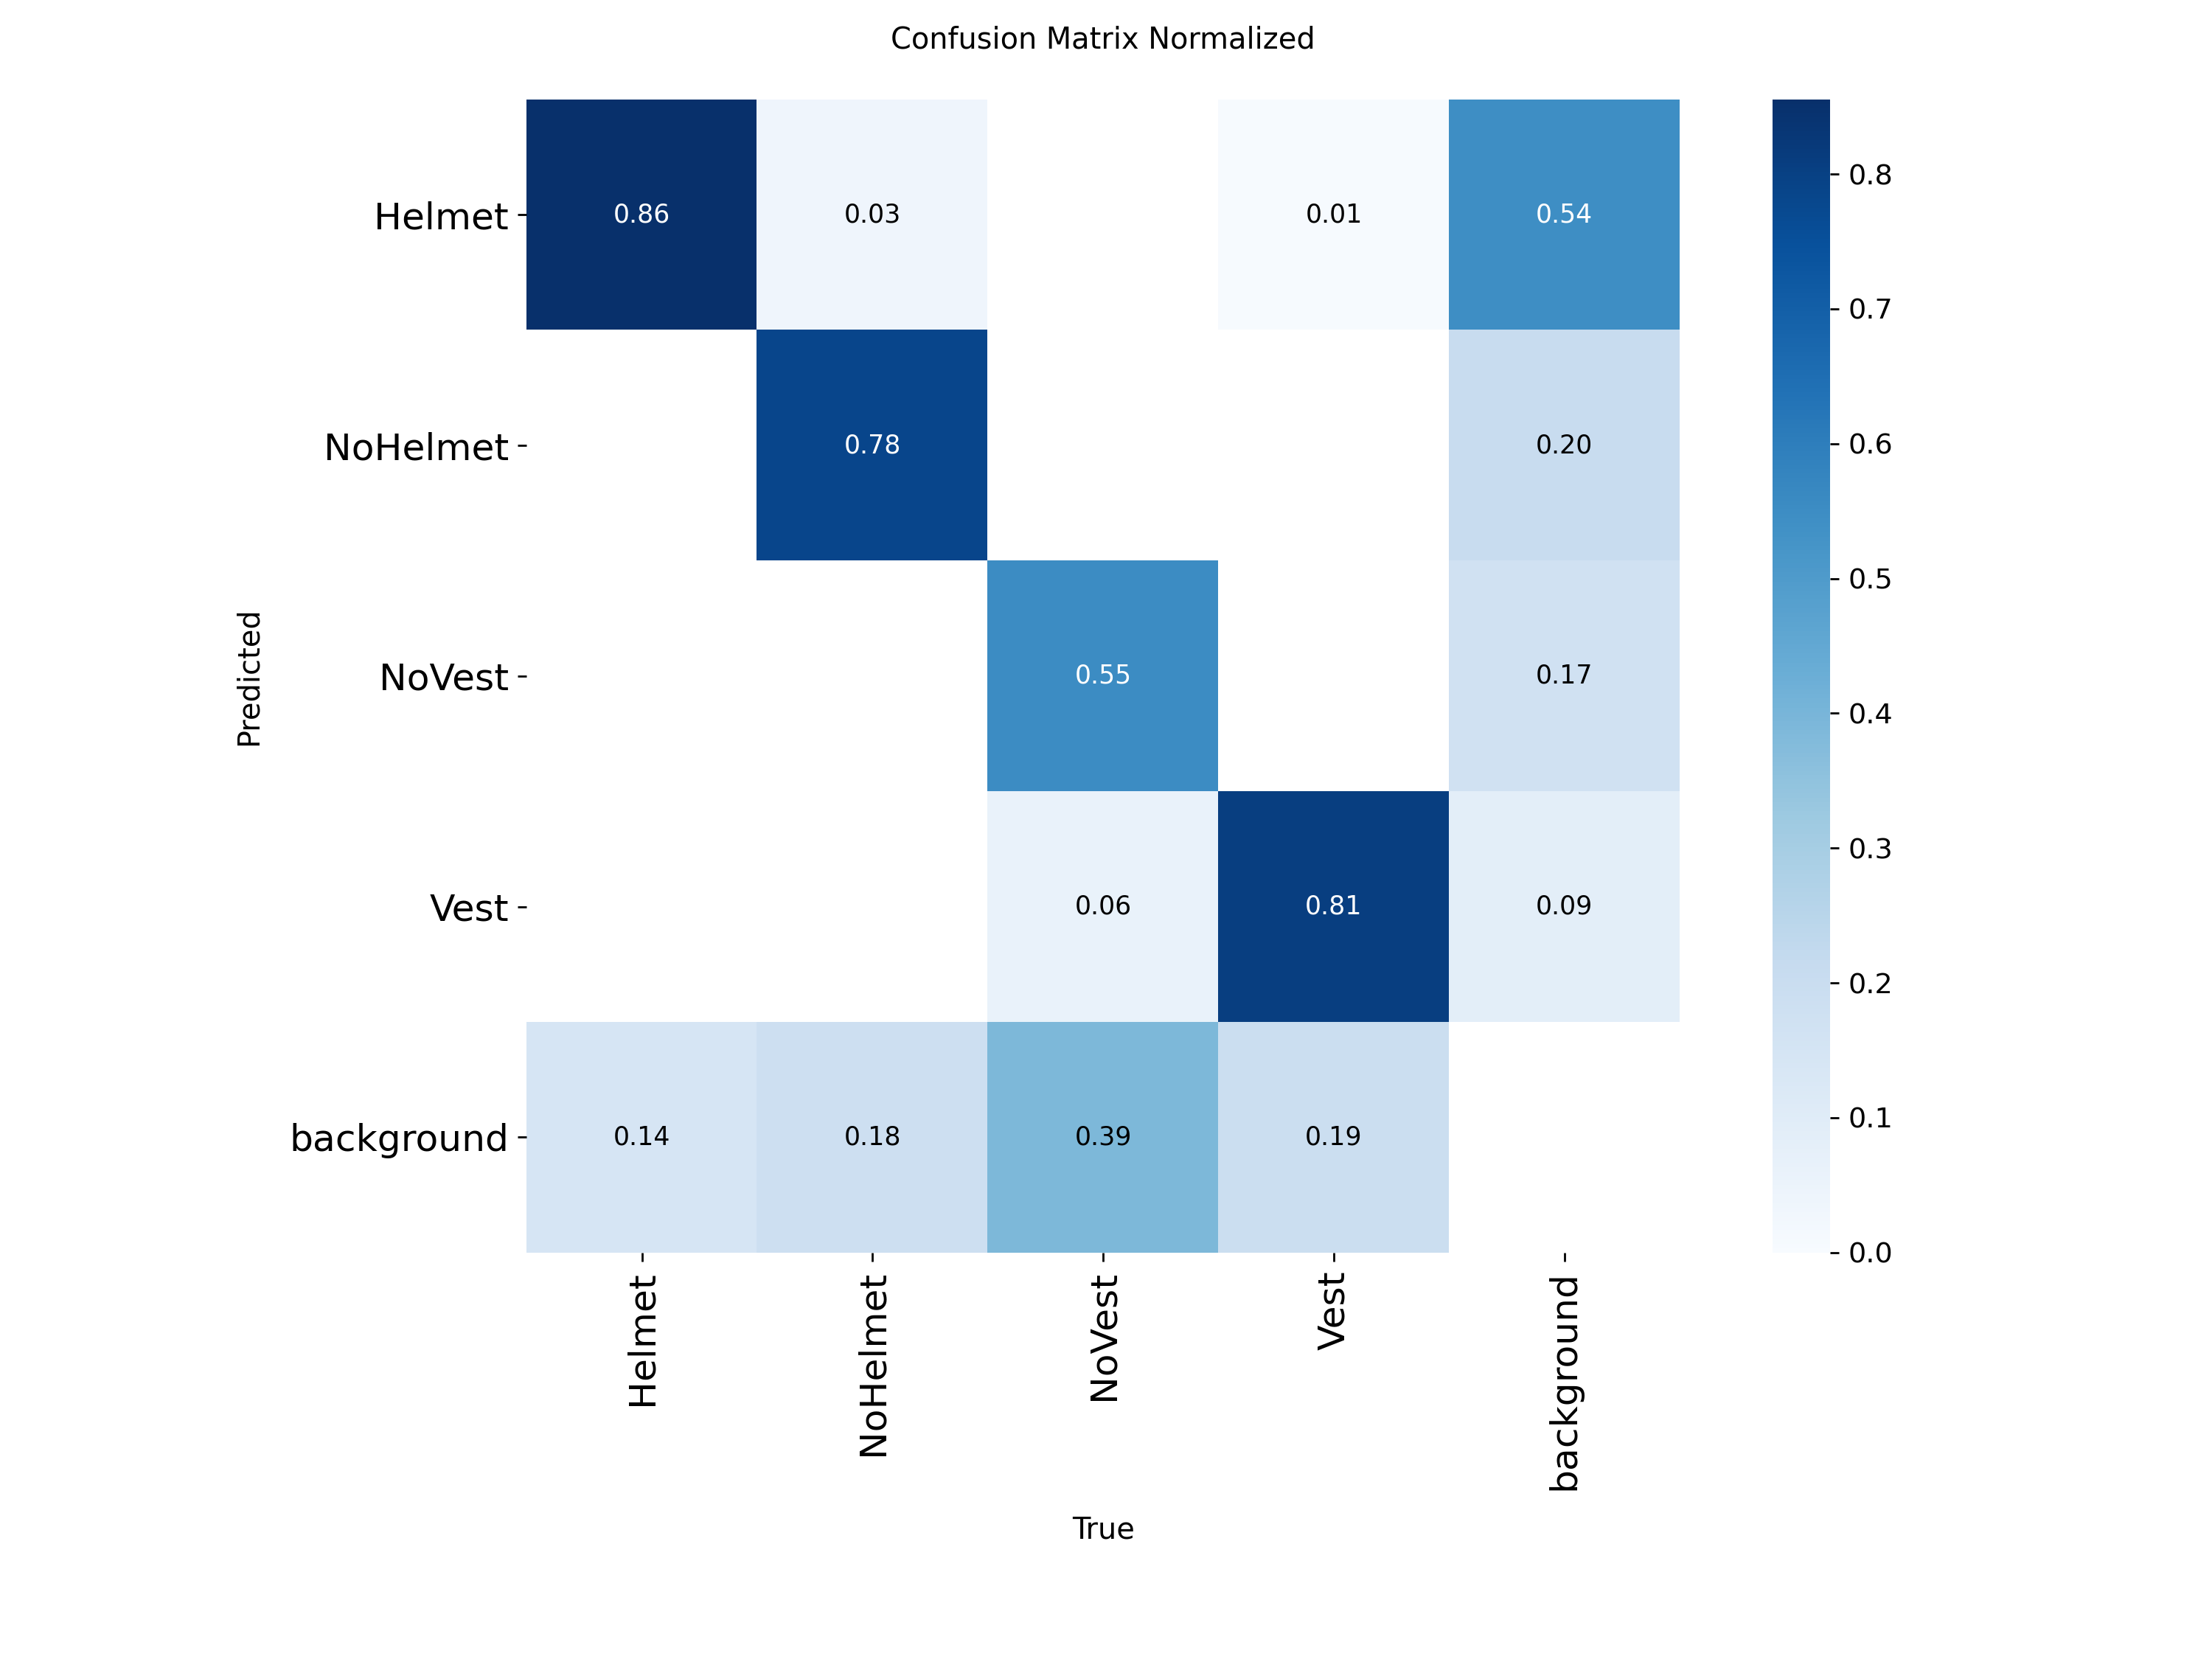

In [18]:
# STEP 12A — Display the Normalized Confusion Matrix
# Purpose: Visualize the model's class-level prediction
# behavior on the unseen test set.


from pathlib import Path
from IPython.display import display, Image

test_results_dir = Path(
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "runs/final_test_evaluation"
)

confusion_matrix_path = (
    test_results_dir / "confusion_matrix_normalized.png"
)

display(Image(filename=str(confusion_matrix_path)))

Precision–Recall Curve


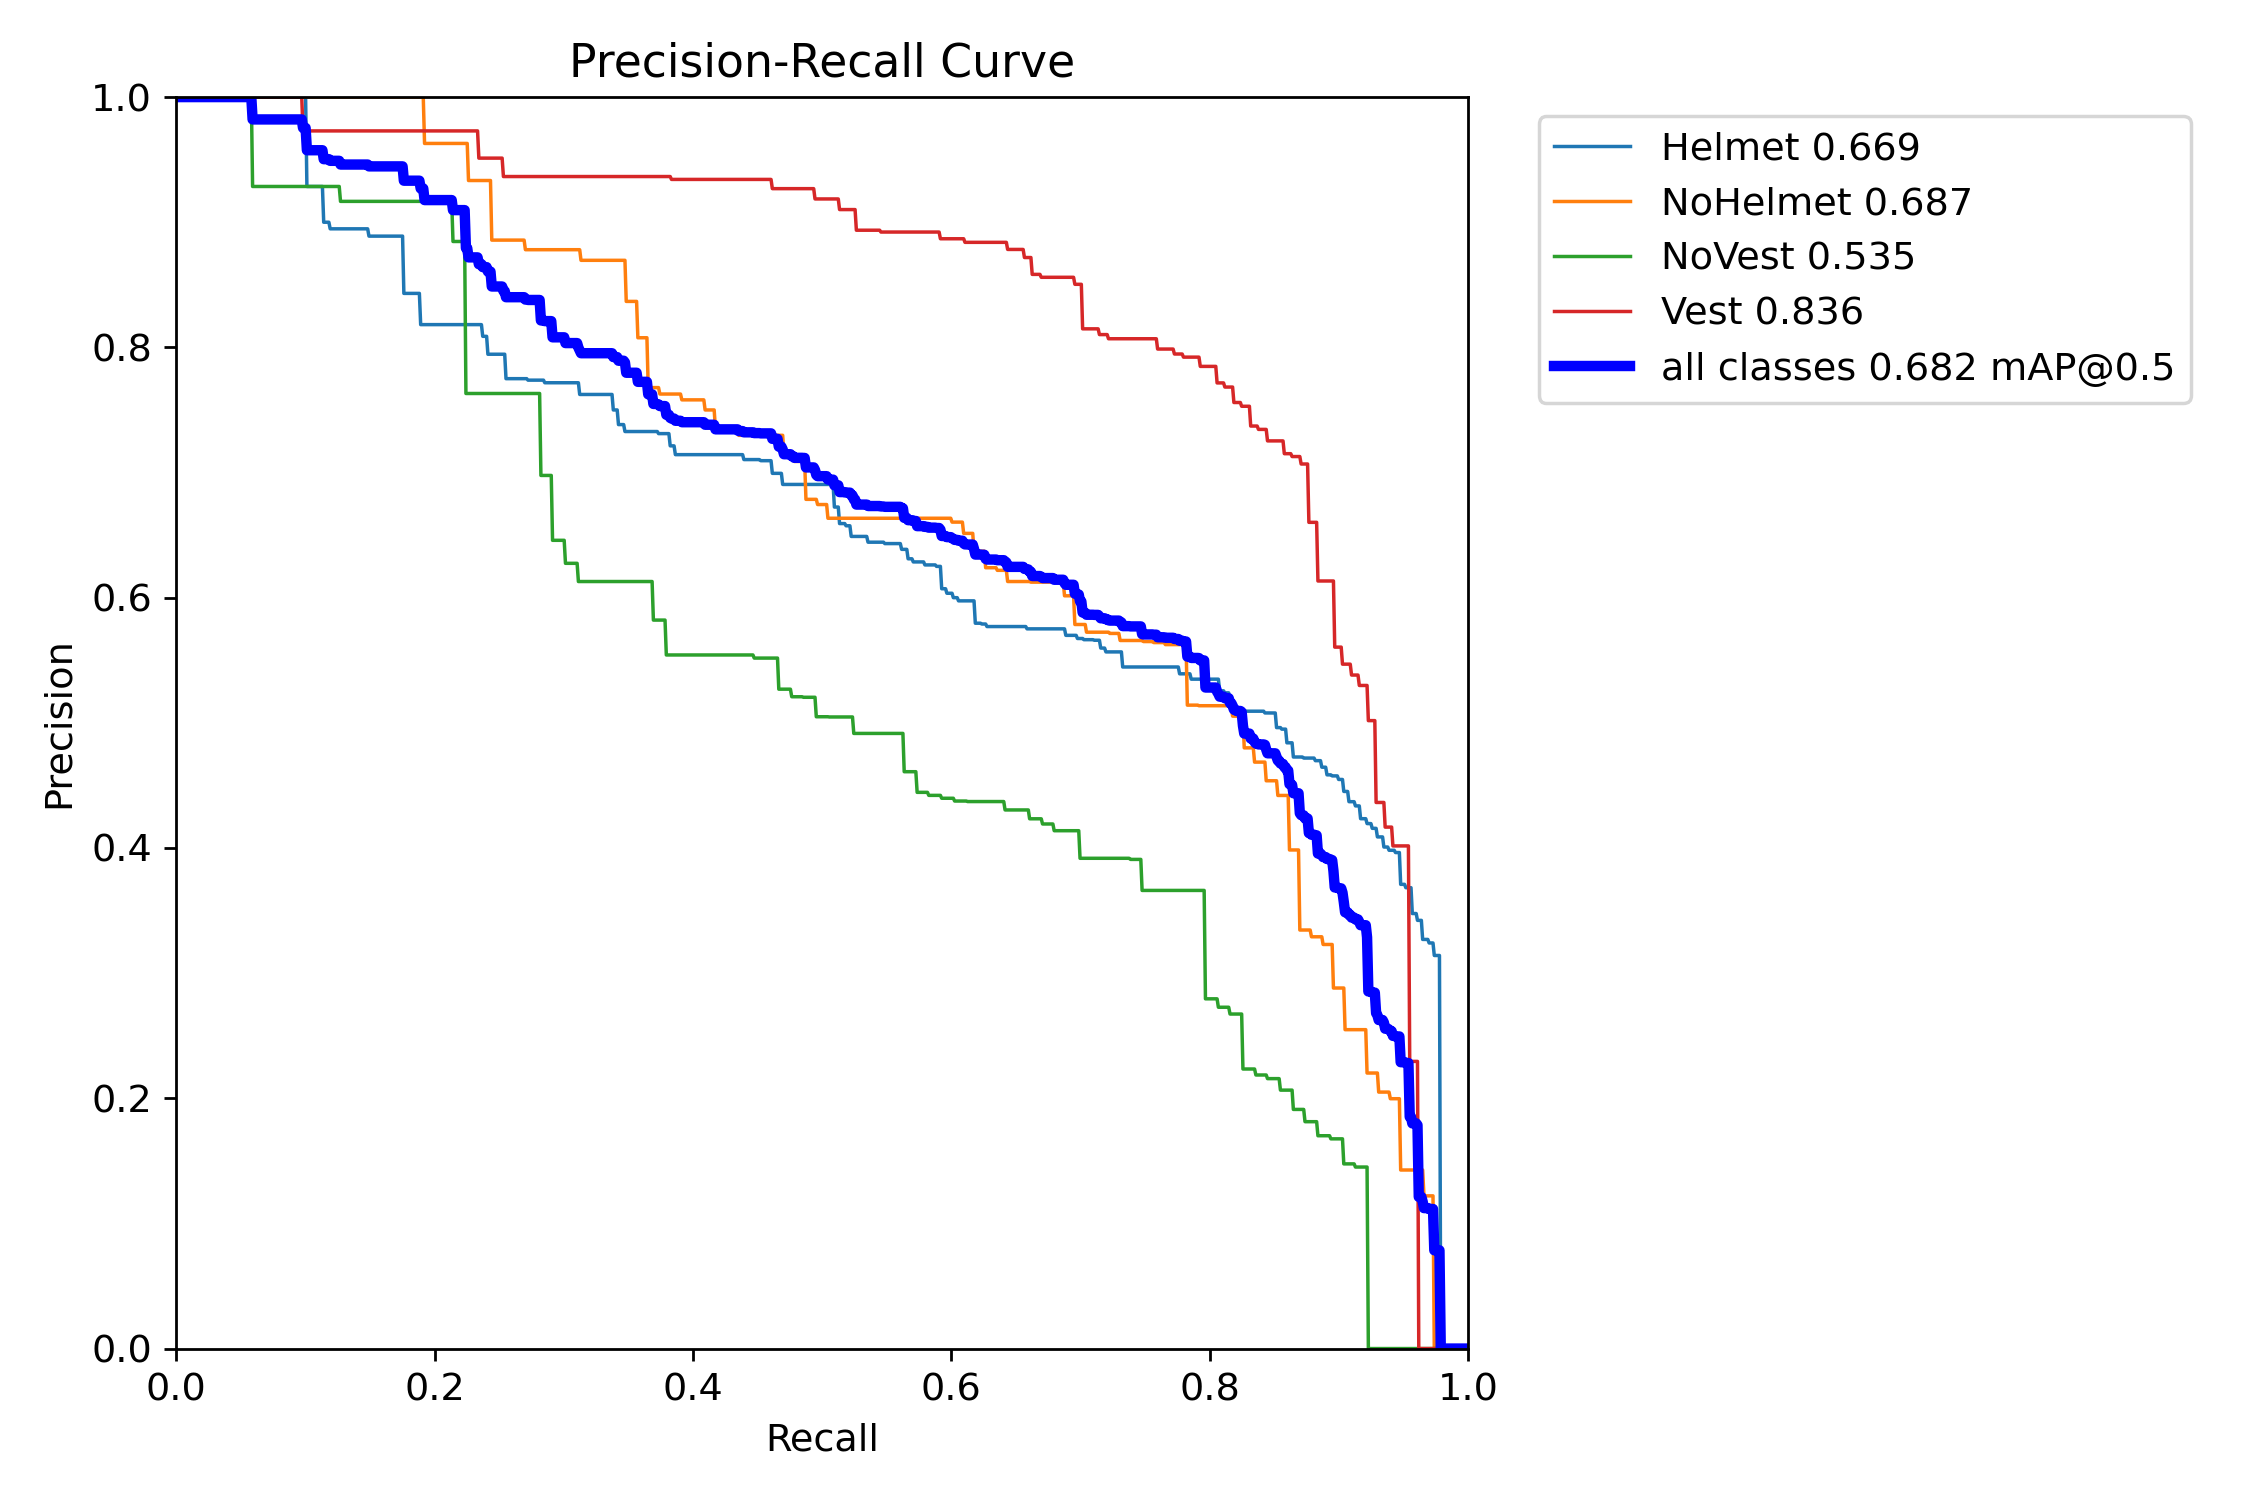


F1–Confidence Curve


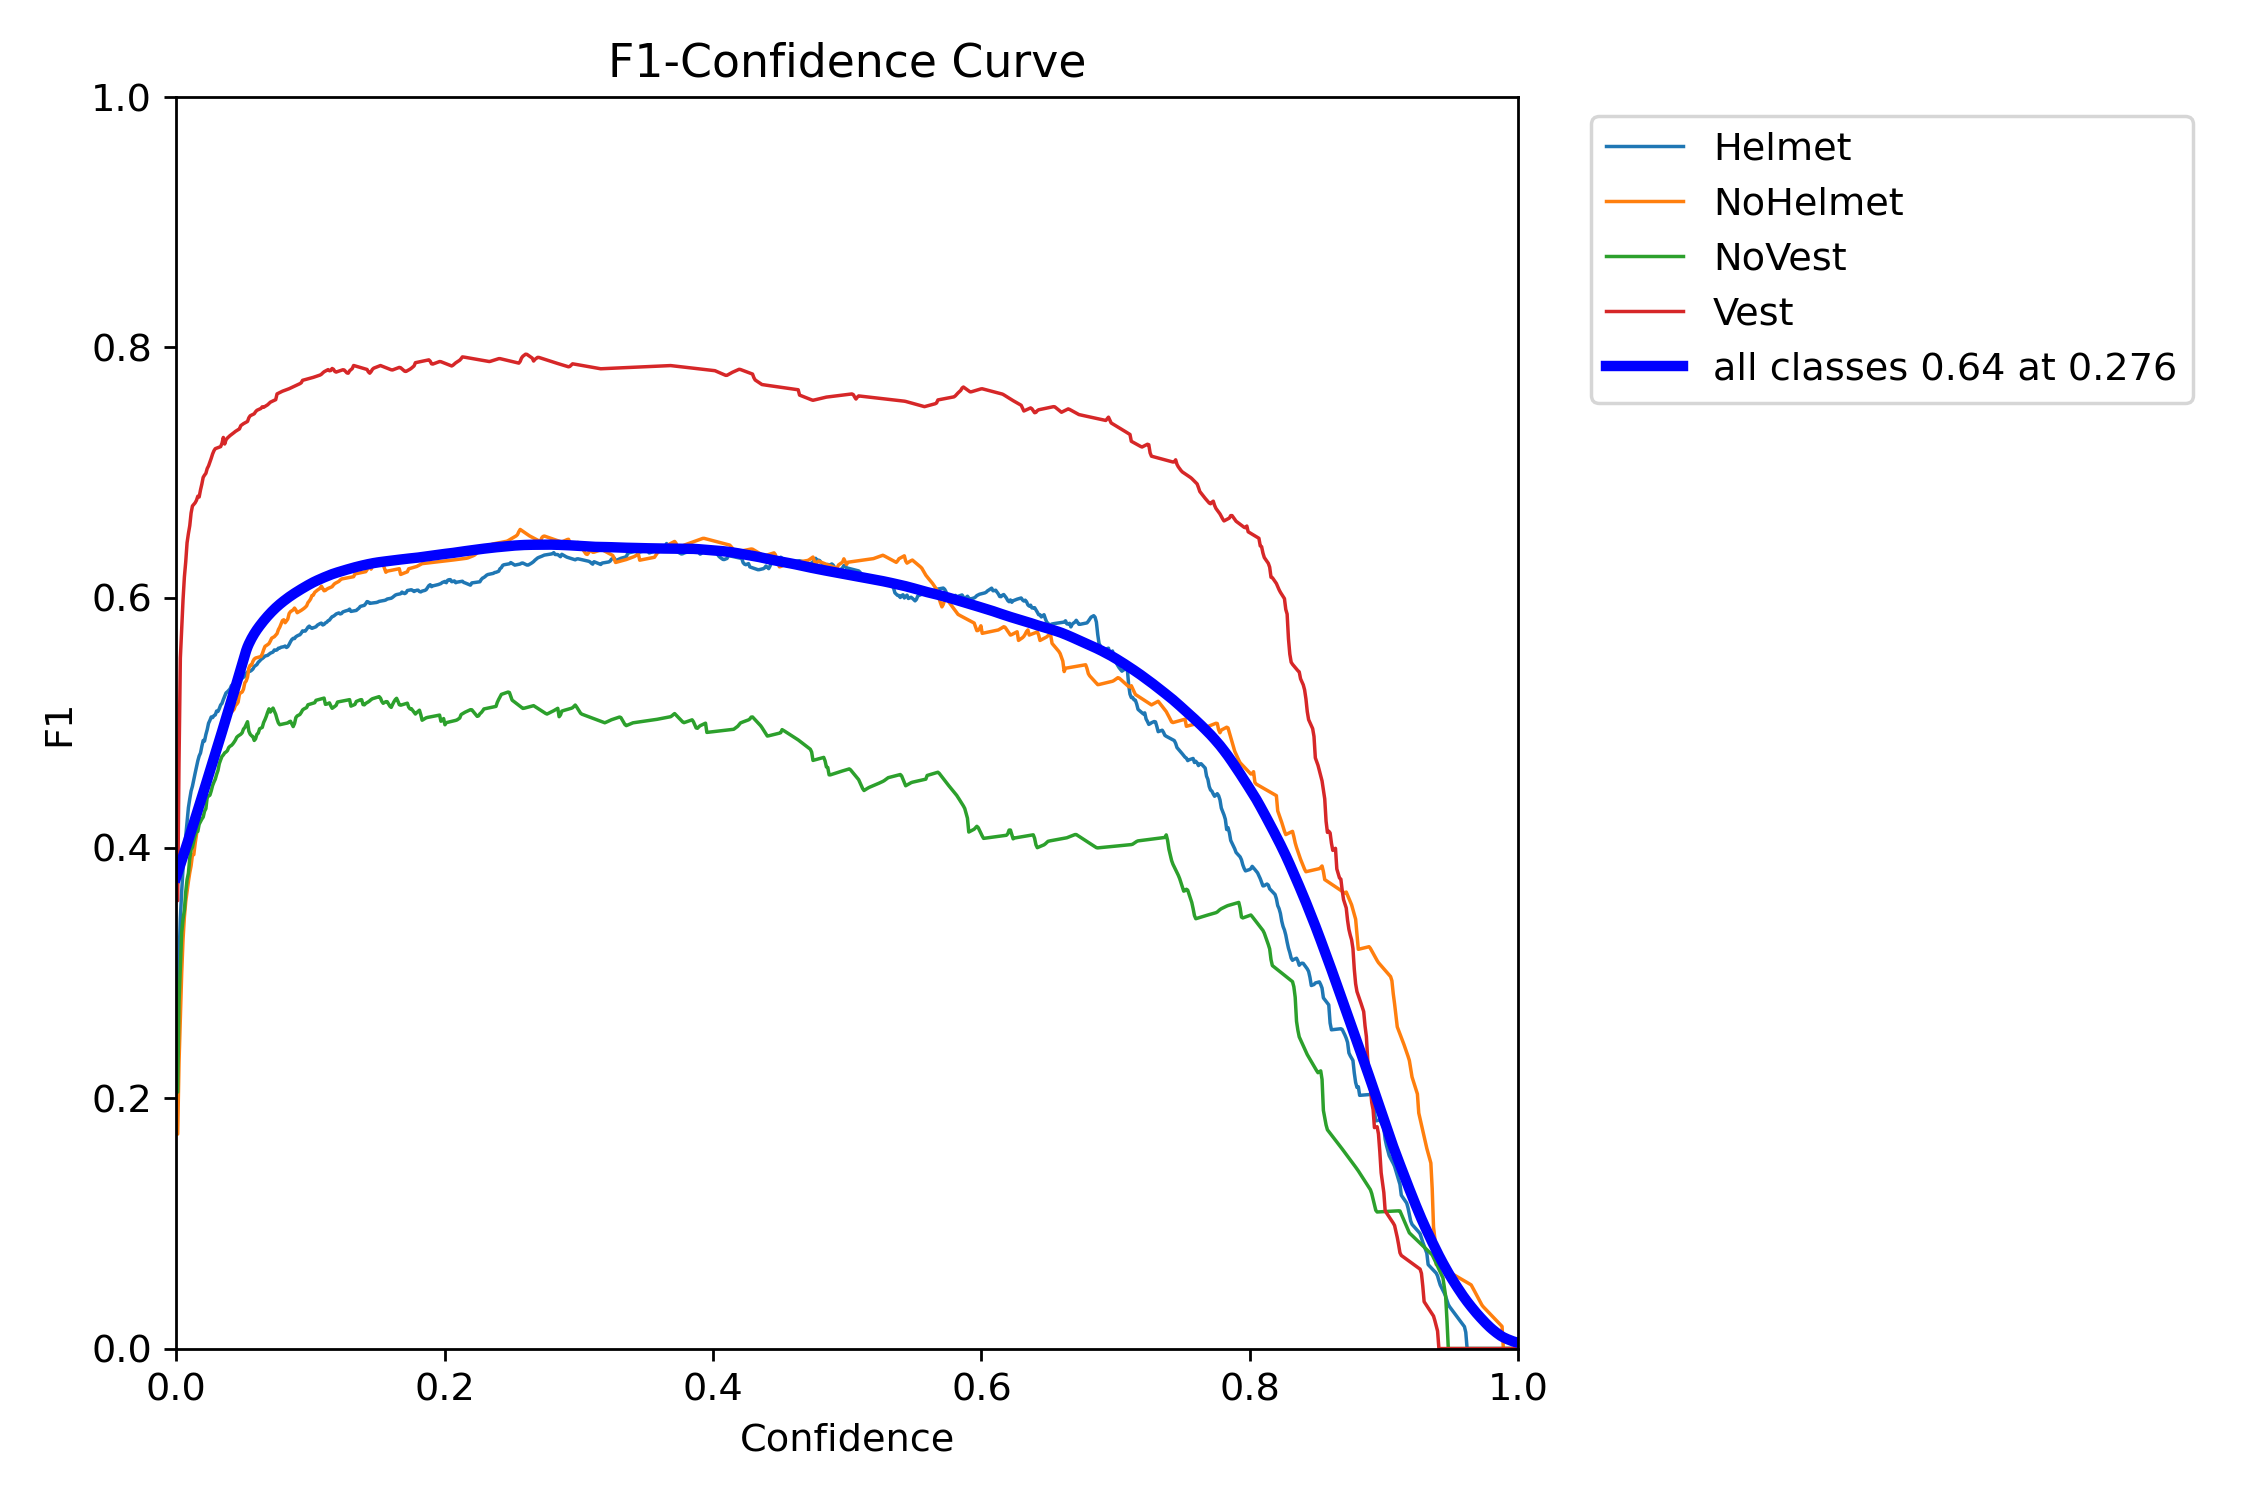

In [6]:
# STEP 12B — Display Precision–Recall and F1–Confidence Curves
# Purpose: Visualize model performance across recall levels
# and confidence thresholds on the final test set.


from pathlib import Path
from IPython.display import display, Image

test_results_dir = Path(
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "runs/final_test_evaluation"
)

print("Precision–Recall Curve")
display(Image(filename=str(test_results_dir / "BoxPR_curve.png")))

print("\nF1–Confidence Curve")
display(Image(filename=str(test_results_dir / "BoxF1_curve.png")))

In [7]:
# STEP 13 — Analyze Test Predictions and Identify Success/Failure Cases
# Purpose: Compare model predictions with ground-truth labels
# on the unseen test set using IoU ≥ 0.5 and class matching.
# This helps identify genuine successful and failure examples
# for qualitative model evaluation.


from pathlib import Path
import pandas as pd
from ultralytics import YOLO

# Paths and model

test_images_dir = Path(
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "datasets/PPE_Dataset_Final/test/images"
)

test_labels_dir = Path(
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "datasets/PPE_Dataset_Final/test/labels"
)

best_model_path = (
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "runs/refined_data_baseline_yolo26n/weights/best.pt"
)

model = YOLO(best_model_path)

class_names = ["Helmet", "NoHelmet", "NoVest", "Vest"]

# IoU function

def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0



# Read YOLO ground-truth labels
def read_ground_truth(label_path, image_width, image_height):
    ground_truth = []

    if not label_path.exists():
        return ground_truth

    with open(label_path, "r") as file:
        for line in file:
            values = line.strip().split()

            if len(values) < 5:
                continue

            class_id = int(values[0])

            xc = float(values[1]) * image_width
            yc = float(values[2]) * image_height
            w = float(values[3]) * image_width
            h = float(values[4]) * image_height

            ground_truth.append({
                "class_id": class_id,
                "box": [
                    xc - w / 2,
                    yc - h / 2,
                    xc + w / 2,
                    yc + h / 2
                ]
            })

    return ground_truth


# Run inference on the entire Test set
predictions = model.predict(
    source=str(test_images_dir),
    imgsz=640,
    conf=0.25,
    device=0,
    verbose=False
)

analysis = []


# Compare Predictions vs Ground Truth
for result in predictions:

    image_path = Path(result.path)
    height, width = result.orig_shape

    label_path = test_labels_dir / f"{image_path.stem}.txt"

    ground_truth = read_ground_truth(
        label_path,
        width,
        height
    )

    predicted_boxes = []

    if result.boxes is not None:
        for box in result.boxes:

            predicted_boxes.append({
                "class_id": int(box.cls.item()),
                "confidence": float(box.conf.item()),
                "box": box.xyxy[0].cpu().tolist()
            })

    matched_predictions = set()
    correct_matches = 0

    # Match each GT object with the best unused prediction
    for gt in ground_truth:

        best_iou = 0
        best_prediction = None

        for pred_index, pred in enumerate(predicted_boxes):

            if pred_index in matched_predictions:
                continue

            if pred["class_id"] != gt["class_id"]:
                continue

            iou = calculate_iou(gt["box"], pred["box"])

            if iou > best_iou:
                best_iou = iou
                best_prediction = pred_index

        if best_iou >= 0.5:
            correct_matches += 1
            matched_predictions.add(best_prediction)

    gt_count = len(ground_truth)
    pred_count = len(predicted_boxes)

    false_negatives = gt_count - correct_matches
    false_positives = pred_count - correct_matches

    # Image-level classification for qualitative analysis
    if (
        gt_count > 0
        and correct_matches == gt_count
        and false_positives == 0
    ):
        case_type = "Success"
    else:
        case_type = "Failure"

    analysis.append({
        "image": image_path.name,
        "ground_truth_objects": gt_count,
        "predicted_objects": pred_count,
        "correct_matches": correct_matches,
        "false_negatives": false_negatives,
        "false_positives": false_positives,
        "case": case_type
    })


# Create analysis table
analysis_df = pd.DataFrame(analysis)

print("--- Test Prediction Analysis ---\n")

print("Total test images:", len(analysis_df))
print(
    "Successful images:",
    (analysis_df["case"] == "Success").sum()
)
print(
    "Failure images:",
    (analysis_df["case"] == "Failure").sum()
)

print("\n--- Example Successful Cases ---")

display(
    analysis_df[
        analysis_df["case"] == "Success"
    ].head(10)
)

print("\n--- Example Failure Cases ---")

display(
    analysis_df[
        analysis_df["case"] == "Failure"
    ].sort_values(
        ["false_negatives", "false_positives"],
        ascending=False
    ).head(10)
)

--- Test Prediction Analysis ---

Total test images: 229
Successful images: 60
Failure images: 169

--- Example Successful Cases ---


,image,ground_truth_objects,predicted_objects,correct_matches,false_negatives,false_positives,case
0,00006_jpg.rf.a5e92b1b35a669039eb07b64915edca8.jpg,1,1,1,0,0,Success
1,00009_jpg.rf.adeb008e3b04cd58befe5103ef49f566.jpg,4,4,4,0,0,Success
2,00016_jpg.rf.a5de42674ff1996a69f005db19136b4e.jpg,1,1,1,0,0,Success
5,00044_jpg.rf.3ff76c92c1562db53886f48f7c2bc837.jpg,1,1,1,0,0,Success
6,00054_jpg.rf.11c3d4c33e8691dea0e404b1f3d18659.jpg,4,4,4,0,0,Success
14,00130_jpg.rf.6b8c97f352a6ba21223dbf00aa3cbfc7.jpg,2,2,2,0,0,Success
15,00142_jpg.rf.19e4c8efef57e274fdb2b59c4ccbffa9.jpg,2,2,2,0,0,Success
28,00271_jpg.rf.552f8454b359211a49f5cffb6fbffb4a.jpg,1,1,1,0,0,Success
37,00376_jpg.rf.154f7856cb8fea0fbafda6eccb42a612.jpg,2,2,2,0,0,Success
40,00407_jpg.rf.d4867bbb81650fe88bb3ee4f918c59a7.jpg,2,2,2,0,0,Success



--- Example Failure Cases ---


,image,ground_truth_objects,predicted_objects,correct_matches,false_negatives,false_positives,case
25,00262_jpg.rf.ff4368635f2514d6ca2fbc5a5ff33850.jpg,10,7,5,5,2,Failure
32,00301_jpg.rf.4f960bd6566f4f7824887fff600fb504.jpg,4,13,0,4,13,Failure
139,03223_jpg.rf.d780b0b4719c8e4a0e11fdd1da6e5754.jpg,9,6,5,4,1,Failure
10,00103_jpg.rf.509ee876d0d9b471a77304f178ea21a6.jpg,8,4,4,4,0,Failure
36,00338_jpg.rf.406122e3644ac7d2accc77c21f43c6d5.jpg,3,8,0,3,8,Failure
156,1027202403_jpg.rf.5d5af5ba642c7ae1a6b24632e45c...,8,11,5,3,6,Failure
4,00040_jpg.rf.42fbdc3f78504ab5afd69aa2393a5d5e.jpg,4,6,1,3,5,Failure
80,00925_jpg.rf.9de2c7ad34130ef5293a68dc36f4aa2f.jpg,4,6,1,3,5,Failure
150,03332_jpg.rf.26cfd1b75737151100b333df1b332f85.jpg,3,5,0,3,5,Failure
29,00273_jpg.rf.ae794def3271ef46362c92083f8c0f40.jpg,3,3,0,3,3,Failure


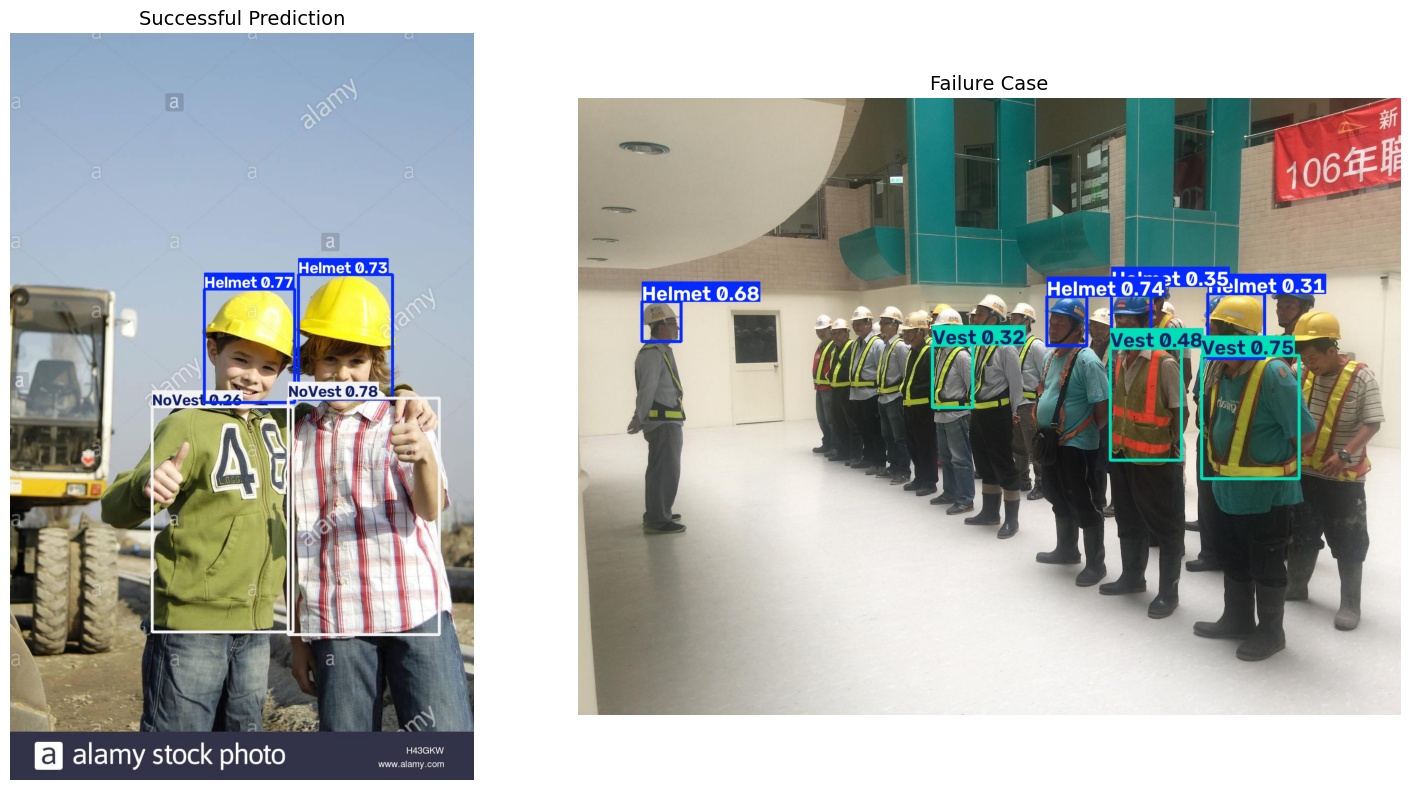

In [8]:
# STEP 14 — Visualize Successful and Failure Predictions
# Purpose: Display one representative successful prediction
# and one failure case from the unseen test set for qualitative
# evaluation and error analysis.

from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Select representative test cases
success_image_name = (
    "00009_jpg.rf.adeb008e3b04cd58befe5103ef49f566.jpg"
)

failure_image_name = (
    "00262_jpg.rf.ff4368635f2514d6ca2fbc5a5ff33850.jpg"
)

selected_images = [
    ("Successful Prediction", success_image_name),
    ("Failure Case", failure_image_name)
]


# Run prediction and display results

plt.figure(figsize=(16, 8))

for index, (title, image_name) in enumerate(selected_images, start=1):

    image_path = test_images_dir / image_name

    # Run inference
    result = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )[0]

    # Ultralytics automatically draws:
    # Bounding boxes + Class names + Confidence scores
    annotated_image = result.plot()

    # Convert BGR → RGB for Matplotlib
    annotated_image = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(1, 2, index)
    plt.imshow(annotated_image)
    plt.title(title, fontsize=14)
    plt.axis("off")

plt.tight_layout()
plt.show()

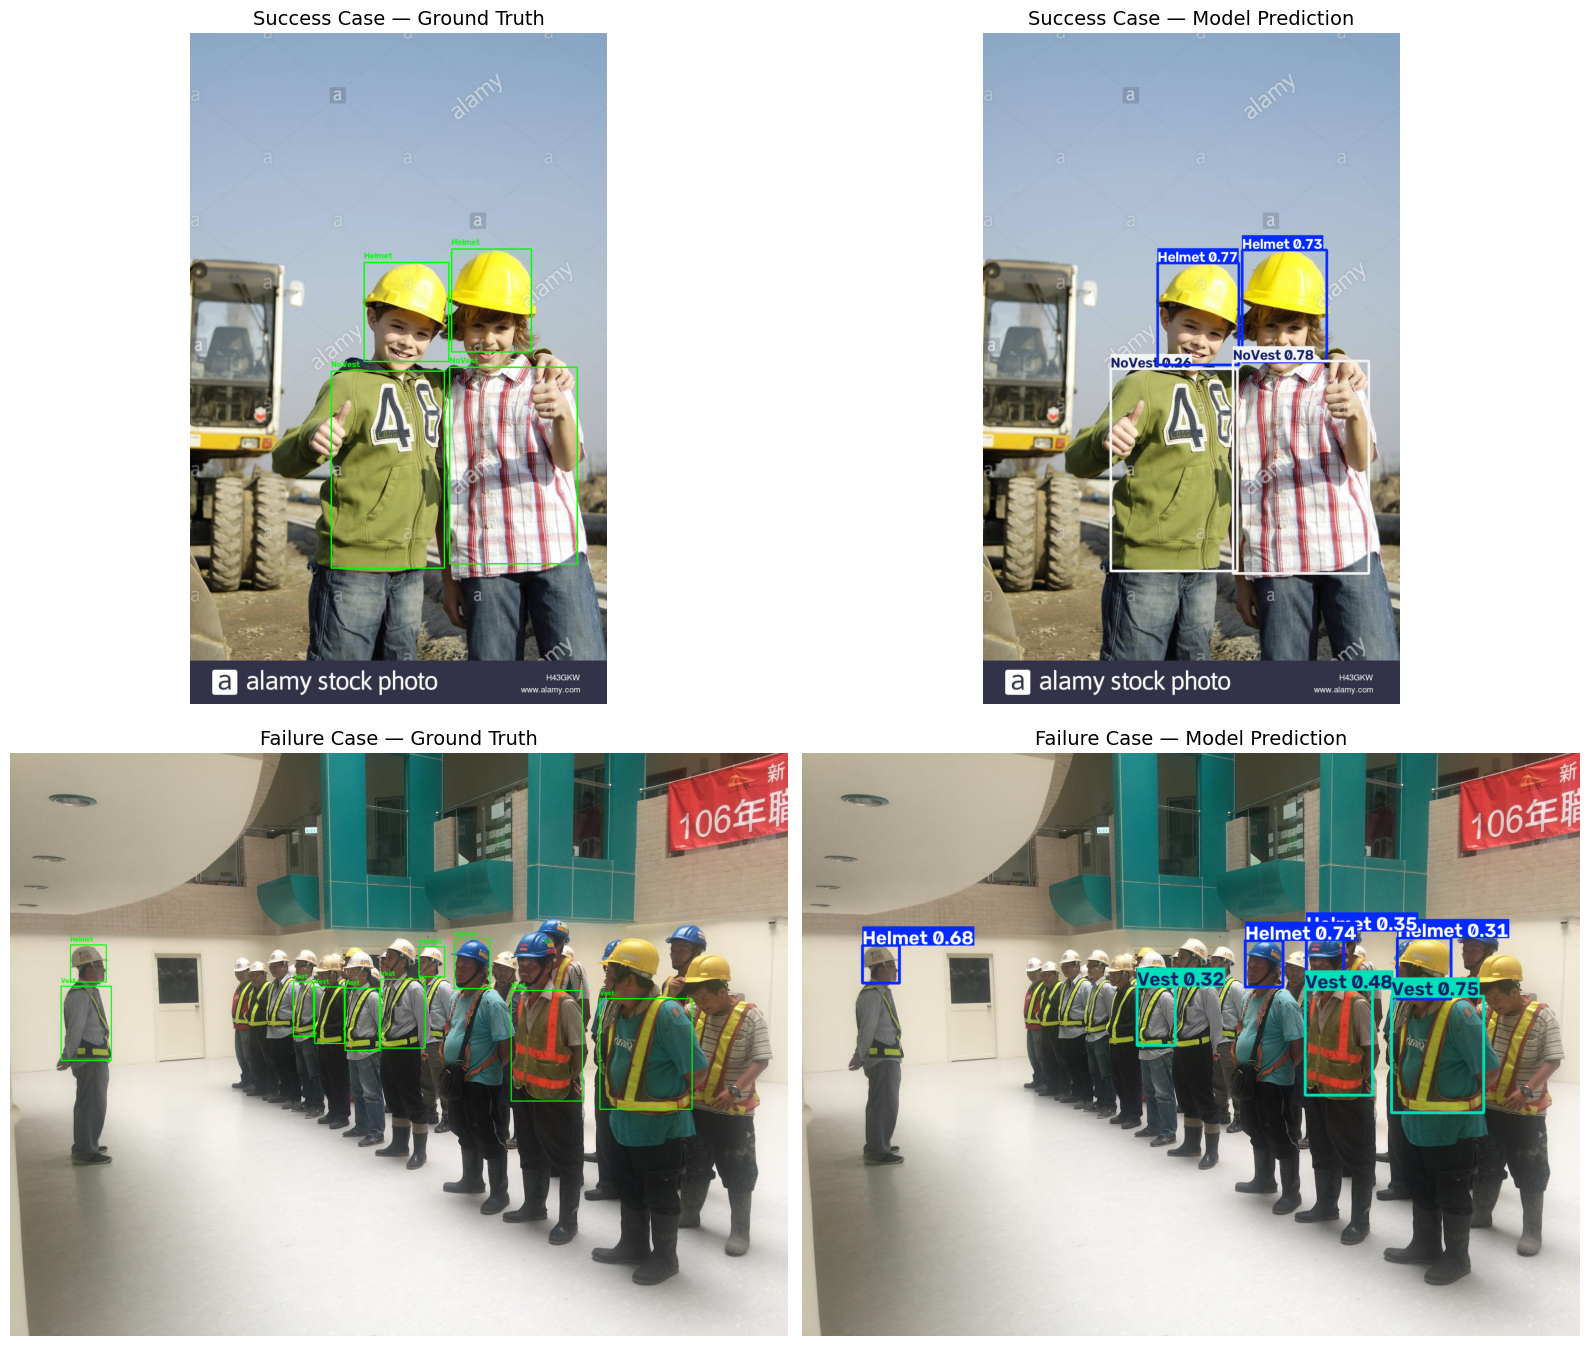

In [9]:
# STEP 15 — Compare Ground Truth with Model Predictions
# Purpose: Visually compare the true PPE annotations with the
# model predictions for one successful case and one failure
# case from the unseen test set.

from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Class names

class_names = ["Helmet", "NoHelmet", "NoVest", "Vest"]


# Selected test examples
success_image_name = (
    "00009_jpg.rf.adeb008e3b04cd58befe5103ef49f566.jpg"
)

failure_image_name = (
    "00262_jpg.rf.ff4368635f2514d6ca2fbc5a5ff33850.jpg"
)


# Function to draw Ground Truth annotations

def draw_ground_truth(image_path, label_path):

    image = cv2.imread(str(image_path))
    height, width = image.shape[:2]

    with open(label_path, "r") as file:

        for line in file:

            values = line.strip().split()

            class_id = int(values[0])

            x_center = float(values[1]) * width
            y_center = float(values[2]) * height
            box_width = float(values[3]) * width
            box_height = float(values[4]) * height

            x1 = int(x_center - box_width / 2)
            y1 = int(y_center - box_height / 2)
            x2 = int(x_center + box_width / 2)
            y2 = int(y_center + box_height / 2)

            label = class_names[class_id]

            # Draw bounding box
            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            # Draw class label
            cv2.putText(
                image,
                label,
                (x1, max(y1 - 8, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# Function to generate Model Prediction visualization
def draw_prediction(image_path):

    result = model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )[0]

    prediction_image = result.plot()

    return cv2.cvtColor(
        prediction_image,
        cv2.COLOR_BGR2RGB
    )



# Prepare paths
success_image_path = test_images_dir / success_image_name
success_label_path = (
    test_labels_dir / f"{Path(success_image_name).stem}.txt"
)

failure_image_path = test_images_dir / failure_image_name
failure_label_path = (
    test_labels_dir / f"{Path(failure_image_name).stem}.txt"
)


# Generate Ground Truth images
success_gt = draw_ground_truth(
    success_image_path,
    success_label_path
)

failure_gt = draw_ground_truth(
    failure_image_path,
    failure_label_path
)


# Generate Prediction images
success_pred = draw_prediction(success_image_path)
failure_pred = draw_prediction(failure_image_path)



# Display comparison
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 14)
)

# Successful case
axes[0, 0].imshow(success_gt)
axes[0, 0].set_title(
    "Success Case — Ground Truth",
    fontsize=14
)
axes[0, 0].axis("off")

axes[0, 1].imshow(success_pred)
axes[0, 1].set_title(
    "Success Case — Model Prediction",
    fontsize=14
)
axes[0, 1].axis("off")


# Failure case
axes[1, 0].imshow(failure_gt)
axes[1, 0].set_title(
    "Failure Case — Ground Truth",
    fontsize=14
)
axes[1, 0].axis("off")

axes[1, 1].imshow(failure_pred)
axes[1, 1].set_title(
    "Failure Case — Model Prediction",
    fontsize=14
)
axes[1, 1].axis("off")


plt.tight_layout()
plt.show()

In [10]:
# STEP 16A — Install Gradio
# Purpose: Install Gradio for the interactive PPE detection
# demonstration.

!pip install -q gradio

In [15]:
# STEP 16B — Build the Interactive PPE Detection Demo
# Purpose: Create a Gradio interface for image-based PPE
# detection and violation summarization.


import gradio as gr
import cv2
from collections import Counter
from ultralytics import YOLO


# Load the final trained model
best_model_path = (
    "/content/drive/MyDrive/PPE_Compliance_Project/"
    "runs/refined_data_baseline_yolo26n/weights/best.pt"
)

app_model = YOLO(best_model_path)


# PPE detection function
def detect_ppe(image):

    if image is None:
        return None, "Please upload an image."

    # Run YOLO inference
    result = app_model.predict(
        source=image,
        imgsz=640,
        conf=0.25,
        device=0,
        verbose=False
    )[0]

    # Draw bounding boxes and confidence scores
    annotated_image = result.plot()

    # Convert BGR → RGB for Gradio
    annotated_image = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )


    # Count detected PPE classes
    detected_classes = []

    if result.boxes is not None:

        for class_id in result.boxes.cls.tolist():

            class_name = app_model.names[int(class_id)]
            detected_classes.append(class_name)

    counts = Counter(detected_classes)

    helmet_count = counts.get("Helmet", 0)
    no_helmet_count = counts.get("NoHelmet", 0)
    vest_count = counts.get("Vest", 0)
    no_vest_count = counts.get("NoVest", 0)


    # Determine detected violations

    violations = no_helmet_count + no_vest_count

    if violations > 0:

        status = (
            f"{violations} PPE violation detection(s) found."
        )

    elif (
        helmet_count > 0
        or vest_count > 0
    ):

        status = (
            "No PPE violation classes were detected. "
            "Compliance may still be incomplete if some PPE "
            "items were not detected."
        )

    else:

        status = (
            "PPE compliance could not be determined from "
            "the detected objects."
        )


    # Generate detection summary

    summary = f"""
PPE Detection Summary

Helmet: {helmet_count}
No Helmet: {no_helmet_count}
Vest: {vest_count}
No Vest: {no_vest_count}

Detected Violations: {violations}

Status:
{status}
"""

    return annotated_image, summary



# Build Gradio interface

demo = gr.Interface(

    fn=detect_ppe,

    inputs=gr.Image(
           type="filepath",
           label="Upload Construction Site Image"
    ),

    outputs=[
        gr.Image(
            type="numpy",
            label="PPE Detection Result"
        ),

        gr.Textbox(
            label="Compliance Summary",
            lines=10
        )
    ],

    title="AI-Based PPE Compliance Monitoring System",

    description=(
        "Upload a construction-site image to detect helmets, "
        "safety vests, and potential PPE violations using "
        "a fine-tuned YOLO26n object detection model."
    )
)


# Launch application

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f5322028b919a35895.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Conclusion

This project developed an end-to-end PPE object detection system using a fine-tuned YOLO26n model.

The final model was trained to detect four PPE-related classes: **Helmet, NoHelmet, NoVest, and Vest**, and was evaluated on a dedicated unseen test set.

The system achieved an overall **mAP@50 of 0.682** and **mAP@50–95 of 0.487**. Qualitative evaluation showed successful PPE detection in clear scenes, while crowded scenes, small objects, and the NoVest class remained more challenging.

Finally, the trained model was integrated into an interactive Gradio interface, demonstrating image-based PPE detection and violation summarization.

## Future Improvements

Future work could include:

- Expanding and diversifying the PPE dataset.
- Improving detection of the NoVest class and small or partially occluded PPE objects.
- Adding person detection and worker-to-PPE association for individual compliance assessment.
- Evaluating the system on video and real-time camera streams.
- Exploring model export and optimization for edge or production deployment.